# Сервис аренды самокатов GoFast: проверка продуктовых гипотез

**Задача.** Проанализировать демографию пользователей и поведение в поездках, посчитать выручку и проверить гипотезы о выгоде платной подписки Ultra по сравнению с бесплатным тарифом Free.

**Данные.** Три таблицы за один год: пользователи (возраст, город, тип подписки), поездки (дистанция, длительность, дата) и тарифы (цена минуты, цена старта, абонентская плата).

**План работы:**
1. Загрузка данных
2. Предобработка
3. Исследовательский анализ
4. Объединение данных
5. Расчёт помесячной выручки
6. Проверка гипотез (t-тесты)
7. Моделирование распределений (CDF / PPF)
8. Итоговый вывод

## Описание данных

Таблица с пользователями `users_go.csv`

- `user_id` — уникальный идентификатор пользователя.

- `name` — имя пользователя.

- `age` — возраст.

- `city` — город.

- `subscription_type` — тип подписки: `free`, `ultra`.

Таблица с поездками `rides_go.csv`

- `user_id` — уникальный идентификатор пользователя.

- `distance` — расстояние в метрах, которое пользователь проехал в текущей сессии.

- `duration` — продолжительность сессии в минутах, то есть время с того момента, как пользователь нажал кнопку «Начать поездку», до того, как он нажал кнопку «Завершить поездку».

- `date` — дата совершения поездки.

Таблица с подписками `subscriptions_go.csv`

- `subscription_type` — тип подписки.

- `minute_price` — стоимость одной минуты поездки по этой подписке.

- `start_ride_price` — стоимость начала поездки.

- `subscription_fee` — стоимость ежемесячного платежа.

---
## 1. Загрузка данных

### 1.1. Импорт библиотеки pandas

In [2]:
import pandas as pd

### 1.2. Чтение данных

In [3]:
df_users_go = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
df_rides_go = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
df_subscriptions_go = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')

### 1.3. Печать первых строк

In [4]:
display(df_users_go.head(5))
display(df_rides_go.head(5))
display(df_subscriptions_go.head(5))

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


### 1.4. Подсчёт строк

In [41]:
print(len(df_users_go), len(df_rides_go), len(df_subscriptions_go))

1534 18068 2


---
## 2. Знакомство с данными и их предварительная подготовка

### 2.1. Определение типов данных

In [6]:
df_rides_go.dtypes

user_id       int64
distance    float64
duration    float64
date         object
dtype: object

### 2.2. Преобразование формата даты

In [7]:
df_rides_go['date'] = pd.to_datetime(df_rides_go['date'])

### 2.3. Создание столбца с месяцем

In [8]:
df_rides_go['month'] = df_rides_go['date'].dt.month

### 2.4. Поиск дублей и пропусков

In [44]:
# Считаем пропущенные значения и полные дубликаты в таблице пользователей
missing_count = df_users_go.isna().sum().sum()
duplicates_count = df_users_go.duplicated().sum()

print(missing_count, duplicates_count)

0 0


### 2.5. Заполнение пропусков и удаление дублей

In [10]:
rows_before = len(df_users_go)
df_users_go = df_users_go.drop_duplicates()
print(f'Удалено полных дубликатов: {rows_before - len(df_users_go)}')

Удалено полных дубликатов: 31


### 2.6. Округление длительности поездки

In [11]:
df_rides_go['duration'] = round(df_rides_go['duration'], 0).astype(int)

---
## 3. Исследовательский анализ данных

### 3.1. Импорт библиотеки matplotlib

In [12]:
import matplotlib.pyplot as plt

### 3.2. Количество пользователей по городам

In [13]:
users_by_city_count = df_users_go['city'].value_counts()

print(users_by_city_count)

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64


### 3.3. Количество пользователей подписки

In [14]:
subscription_type_count = df_users_go['subscription_type'].value_counts()

print(subscription_type_count)

free     835
ultra    699
Name: subscription_type, dtype: int64


### 3.4. Круговая диаграмма

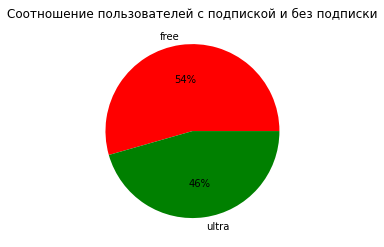

In [15]:
subscription_type_count.plot(
    kind='pie',
    title='Соотношение пользователей с подпиской и без подписки',
    autopct='%.0f%%',
    ylabel='',
    colors=['red', 'green']
)

plt.show()

### 3.5. Гистограмма возрастов

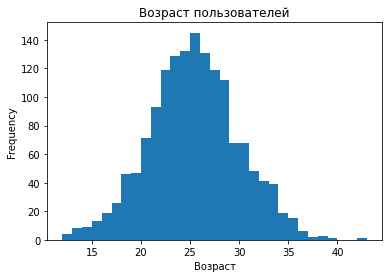

In [16]:
n_bins = df_users_go['age'].max() - df_users_go['age'].min()

df_users_go['age'].hist(bins=n_bins)

plt.title('Возраст пользователей')
plt.xlabel('Возраст')

plt.show()

### 3.6. Несовершеннолетние пользователи

In [46]:
users_under_18_ratio = round((df_users_go['age'] < 18).mean() * 100)
print(f'Доля несовершеннолетних пользователей самокатов составляет {users_under_18_ratio}%.')

Доля несовершеннолетних пользователей самокатов составляет 5%.


### 3.7. Характеристики длительности поездки

In [18]:
duration_mean = round(df_rides_go['duration'].mean())
duration_std = round(df_rides_go['duration'].std())

duration_pct25 = round(df_rides_go['duration'].quantile(0.25))
duration_pct75 = round(df_rides_go['duration'].quantile(0.75))

print(f'Средняя длительность поездки {duration_mean} минут со стандартным отклонением {duration_std}. Основная часть поездок занимает от {duration_pct25} до {duration_pct75} минут.')

Средняя длительность поездки 17.8 минут со стандартным отклонением 6.1. Основная часть поездок занимает от 14.0 до 22.0 минут.


---
## 4. Объединение данных

### 4.1. Объединение таблицы пользователей и поездок

In [19]:
df = df_users_go.merge(df_rides_go, how='left', on='user_id')

display(df)

,user_id,name,age,city,subscription_type,distance,duration,date,month
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8
...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.098080,20,2021-11-04,11
18064,1534,Альберт,25,Краснодар,free,2840.423057,21,2021-11-16,11
18065,1534,Альберт,25,Краснодар,free,3826.185507,18,2021-11-18,11
18066,1534,Альберт,25,Краснодар,free,2902.308661,17,2021-11-27,11


### 4.2. Присоединение информации о подписках

In [20]:
df = df.merge(df_subscriptions_go, how='left', on='subscription_type')

display(df)

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.098080,20,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Краснодар,free,2840.423057,21,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Краснодар,free,3826.185507,18,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Краснодар,free,2902.308661,17,2021-11-27,11,8,50,0


### 4.3. Размеры объединённого датафрейма

In [21]:
# Выводим первые строки датафрейма
display(df.head(5))

# Выводим количество строк и столбцов в объединённом датафрейме
n_rows, n_cols = df.shape
print(f'В полученном датафрейме {n_rows} строк и {n_cols} столбцов.')

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


В полученном датафрейме 18068 строк и 12 столбцов.


### 4.4. Отдельные датафреймы для пользователей с подпиской и без

In [22]:
df_ultra = df[df['subscription_type'] == 'ultra']
df_free = df[df['subscription_type'] == 'free']

### 4.5. Гистограмма длительности поездок для обоих групп

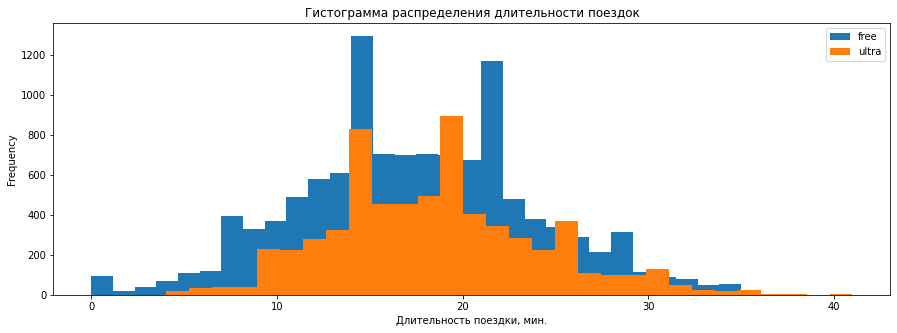

Средняя длительность поездки для пользователей без подписки 17 мин, а для пользователей с подпиской 19 мин


In [47]:
# Гистограмма длительности поездки для пользователей с подпиской и без
plt.figure(figsize=(15, 5))

df_free['duration'].plot(
    kind='hist',
    bins=30,
    label='free'
)

df_ultra['duration'].plot(
    kind='hist',
    bins=30,
    label='ultra'
)


plt.xlabel('Длительность поездки, мин.')
plt.title('Гистограмма распределения длительности поездок')
plt.legend()

plt.show()

# Расчет и вывод на экран средней длительности поездки для пользователей с подпиской и без
mean_duration_free = round(df_free['duration'].mean())
mean_duration_ultra = round(df_ultra['duration'].mean())
print(f'Средняя длительность поездки для пользователей без подписки {mean_duration_free} мин, а для пользователей с подпиской {mean_duration_ultra} мин')

---
## 5. Подсчёт выручки

### 5.1. Данные сгруппированные по нужным колонкам

In [24]:
df_gp = df.groupby(['user_id', 'name', 'subscription_type', 'month'], as_index=False)

### 5.2. Подсчёт агрегированных метрик

In [25]:
df_agg = df_gp.agg(
    total_distance=('distance', 'sum'),
    total_duration=('duration', 'sum'),
    rides_count=('duration', 'count'),
    subscription_type=('subscription_type', 'first'),
    minute_price=('minute_price', 'first'),
    start_ride_price=('start_ride_price', 'first'),
    subscription_fee=('subscription_fee', 'first'),
)

### 5.3. Функция для подсчёта выручки

In [26]:
def calculate_monthly_revenue(row):
    monthly_revenue = ( row['start_ride_price'] * row['rides_count'] 
    + row['minute_price'] * row['total_duration'] 
    + row['subscription_fee'] 
    )
    return monthly_revenue

### 5.4. Создание столбца с месячной выручкой на пользователя

In [27]:
df_agg['monthly_revenue'] = df_agg.apply(calculate_monthly_revenue, axis=1)

### 5.5. Поиск пользователя с максимальной выручкой

In [28]:
df_max_revenue = df_agg.groupby('user_id')['monthly_revenue'].sum()
user_with_max_revenue = df_max_revenue.idxmax()

display(
    df_agg[df_agg['user_id'] == user_with_max_revenue][
        ['user_id', 'name', 'month', 'rides_count', 'monthly_revenue']
    ]
)

,user_id,name,month,rides_count,monthly_revenue
8877,1236,Александр,1,2,228
8878,1236,Александр,2,3,614
8879,1236,Александр,3,5,762
8880,1236,Александр,4,1,202
8881,1236,Александр,5,3,574
8882,1236,Александр,6,1,282
8883,1236,Александр,7,1,290
8884,1236,Александр,8,2,452
8885,1236,Александр,9,1,122
8886,1236,Александр,10,3,430


---
## 6. Проверка гипотез

### 6.1. Импорт библиотеки SciPy

In [29]:
import scipy.stats as st

### 6.2. Вспомогательная функция для интерпретации результатов

In [30]:
def print_stattest_results(p_value: float, alpha: float = 0.05):
    if p_value < alpha:
        print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.')
    else:
        print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.')
    
print_stattest_results(p_value=0.0001)
print_stattest_results(p_value=0.1)

Полученное значение p_value=0.0001 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Полученное значение p_value=0.1 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


### 6.3. Длительность поездок: подписчики vs без подписки

- H0: средняя длительность поездки у пользователей с подпиской и без неё одинаковая.
- H1: у пользователей с подпиской средняя длительность поездки больше.

Независимые выборки, односторонний t-тест, α = 0.05.

In [31]:
ultra_duration = df_ultra['duration']
free_duration = df_free['duration']

results = st.ttest_ind(ultra_duration, free_duration, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value)
ultra_mean_duration = round(df_ultra['duration'].mean(), 2)
free_mean_duration = round(df_free['duration'].mean(), 2)

print(f'Средняя длительность поездки тарифа Ultra {ultra_mean_duration}')
print(f'Средняя длительность поездки тарифа Free {free_mean_duration}')

Полученное значение p_value=1.1540423907706558e-37 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя длительность поездки тарифа Ultra 18.55
Средняя длительность поездки тарифа Free 17.39


### 6.4. Дистанция поездки подписчиков относительно 3130 м

Дистанция 3130 м — оптимальная с точки зрения износа самоката.

- H0: средняя дистанция поездки подписчиков равна 3130 м.
- H1: средняя дистанция поездки подписчиков больше 3130 м.

Одновыборочный односторонний t-тест, α = 0.05.

In [32]:
null_hypothesis = 3130
ultra_distance = df_ultra['distance']

results = st.ttest_1samp(ultra_distance, null_hypothesis, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value)

Полученное значение p_value=0.9195368847849785 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


### 6.5. Помесячная выручка: подписчики vs без подписки

- H0: средняя помесячная выручка с пользователя одинаковая в обеих группах.
- H1: средняя помесячная выручка с подписчика выше.

Независимые выборки, односторонний t-тест, α = 0.05.

In [33]:
revenue_ultra = df_agg[df_agg['subscription_type'] == 'ultra']['monthly_revenue']
revenue_free = df_agg[df_agg['subscription_type'] == 'free']['monthly_revenue']

results = st.ttest_ind(revenue_ultra, revenue_free, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value)

mean_revenue_ultra = round(revenue_ultra.mean())
mean_revenue_free = round(revenue_free.mean())

print(f'Средняя выручка подписчиков Ultra {mean_revenue_ultra} руб')
print(f'Средняя выручка подписчиков Free {mean_revenue_free} руб')

Полученное значение p_value=1.6046721201208006e-47 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя выручка подписчиков Ultra 359 руб
Средняя выручка подписчиков Free 322 руб


---
## 7. Моделирование распределений

Идея продукта — скидка подписчикам за поездки длиннее 30 минут. Оценим долю таких поездок, приблизив длительность поездок подписчиков нормальным распределением с выборочными средним и стандартным отклонением.

### 7.1. Расчёт выборочного среднего и стандартного отклонения

In [34]:
# Вычисляем среднее значение
mu = df_ultra['duration'].mean()

# Вычисляем стандартное отклонение
sigma = df_ultra['duration'].std()

# Задаём целевое время
target_time = 30

print(f'Средняя длительность поездки {round(mu, 1)}, стандартное отклонение {round(sigma, 1)}.')

Средняя длительность поездки 18.5, стандартное отклонение 5.6.


### 7.2. Вычисление значения функции распределения в точке (CDF)

In [35]:
# Вычисляем вероятность того, что случайная величина будет меньше указанного значения или равна ему

duration_norm_dist = st.norm(mu, sigma)
prob = round(1 - duration_norm_dist.cdf(target_time), 3)

print(f'Вероятность поездки более 30 минут {prob}')

Вероятность поездки более 30 минут 0.02


### 7.3. Вероятность для интервала (CDF)

In [39]:
# Определяем границы интервала
low = 20
high = 30

# Вычисляем вероятность попадания в интервал
prob_interval = round(duration_norm_dist.cdf(high) - duration_norm_dist.cdf(low), 3)

print(f'Вероятность того, что пользователь совершит поездку длительностью от {low} до {high} минут: {prob_interval}')

Вероятность того, что пользователь совершит поездку длительностью от 20 до 30 минут: 0.377


### 7.4. Определение критической дистанции поездок (PPF)

In [40]:
# Вычисляем среднее значение
mu = df['distance'].mean()

# Вычисляем стандартное отклонение
sigma = df['distance'].std()

# Вероятность, для которой хотим найти значение (90% случаев)
target_prob = 0.90

# Создаём объект нормального распределения
distance_norm = st.norm(mu, sigma)

# Рассчитываем критическую дистанцию для заданного процентиля поездок
critical_distance = distance_norm.ppf(target_prob)

print(f'{100 * target_prob} % поездок имеют дистанцию ниже критического значения {critical_distance:.2f} М.')

90.0 % поездок имеют дистанцию ниже критического значения 4501.94 М.


---
## 8. Итоговый вывод

**Данные.** 18 068 поездок пользователей из 8 городов (больше всего в Пятигорске, меньше всего в Москве). Пропусков нет, найден и удалён 31 полный дубликат в таблице пользователей. Без подписки ездят 54% пользователей, с подпиской Ultra — 46%. Несовершеннолетних — 5%.

**Поведение в поездках.** Средняя поездка длится 17,8 мин (стандартное отклонение 6,1), половина поездок — от 14 до 22 минут.

**Проверка гипотез (α = 0.05):**
- **Подписчики ездят дольше.** 18,6 мин против 17,4 мин без подписки, p < 0,001 — принимаем H1. Разница статистически значима, но небольшая: около минуты на поездку.
- **Дистанция подписчиков не превышает оптимальные 3130 м.** p = 0,92: оснований считать, что подписчики в среднем ездят дальше оптимума и сильнее изнашивают самокаты, нет.
- **Подписчики приносят больше выручки.** 359 ₽ в месяц против 322 ₽ без подписки (+11%), p < 0,001 — принимаем H1.

**Моделирование распределений:**
- При нормальном приближении поездки подписчиков длиннее 30 минут составляют около **2%**, поэтому скидка на такие поездки затронет мало пользователей.
- Поездки длительностью от 20 до 30 минут — около **38%**: этот интервал больше подходит для промоакции.
- 90% поездок короче **4 502 м**: это значение можно использовать как порог критической дистанции для доплаты.

**Рекомендация.** Развивать подписку Ultra: подписчики приносят больше выручки и при этом не ездят дальше оптимальной для самоката дистанции. Промо для подписчиков лучше привязывать к поездкам длительностью 20–30 минут, а не к редким поездкам длиннее 30 минут.

*Ограничения:* нормальное распределение — приближение; для решения о скидке нужно дополнительно оценить её влияние на выручку.